In [39]:
import random
import numpy as np
import pandas as pd
from math import log
import networkx as nx
from itertools import combinations
from sklearn.metrics import adjusted_rand_score

from freyrelab.regnets import regnet
from freyrelab.regnets.abasy import Abasy
from freyrelab.regnets.regnet import RegNet
from freyrelab.nets import models, dissimilarity

from netective.utils import get_clusters
from netective.structure.structure import pairwise_pearson_correlation, compare_networks, create_symmetric_heatmap

## Networks set

In [12]:
abasy = Abasy(db='abasy_internal', expire_cache=True)
regnet_ids = abasy.select_regnets(nr_strong_wa=True)    # select all regnets without redundancy, keep the strong one if available
regnets = abasy.regnet(regnet_ids)                      # get the regnets {regnet_id: RegNet}


seed = 42
random.seed(seed)
random_graph = {}
hm_seed_size = 3

for net_id, G in regnets.items():
    n = G.number_of_nodes()
    m = G.number_of_edges()
    random_graph[f'BA_{net_id}'] = models.barabasi_albert_graph(n)
    random_graph[f'SF_{net_id}'] = nx.DiGraph(nx.scale_free_graph(n, seed=seed))
    random_graph[f'ER_{net_id}'] = nx.erdos_renyi_graph(n, m/(n*(n-1)), seed=seed, directed=True)
    random_graph[f'HM_{net_id}'] = models.hierarchical_modular_graph(int(log(n, hm_seed_size))-1, m=hm_seed_size)

networks = {**regnets, **random_graph}
networks = {name: RegNet(G) if not isinstance(G, (nx.DiGraph,RegNet)) else G for name, G in networks.items()}

## Compare networks with Netective

In [16]:
scalar, dists = compare_networks(networks=networks, norm='network', return_prop_dicts=True, workers=6)

Properties used for analysis:  Average Clustering Coefficient Average Degree for Nearest Neighbors (Undirected) Average Local Efficiency Average Degree for Nearest Neighbors (Out-Out) Average Shortest Path Length Betweenness Centrality Center Clustering Coefficient Complex Feed-Forward Circuits Density Diameter Eccentricity Entropy of Degree Distribution 3-Feedback Loops Gene % in the Giant Component Gini Index Global Efficiency In-Degree Locality Index Max In-Dregree Max Out-Degree Out-Degree Periphery Radius Regulators Rich Club Coefficient Self-Regulations Subgraph Centrality 



  0%|          | 0/7 [00:00<?, ?it/s]

Running 100226_v2019_sA22-DBSCR15_eStrong
Running 158878_v2015_sRTB13
Running 158879_v2015_sRTB13
Running 160491_v2015_sRTB13
Running 186103_v2015_sRTB13
Running 196620_v2015_sRTB13
Running 196627_v2020_s21_eStrong
Running 198466_v2015_sRTB13
Running 199310_v2015_sRTB13
Running 208964_v2020_sRPA20_eStrong
Running 224308_v2008_sDBTBS08_eStrong
Running 273036_v2015_sRTB13
Running 282458_v2015_sRTB13
Running 282459_v2015_sRTB13
Running 301447_v2015_sRTB13
Running 316385_v2015_sRTB13
Running 319701_v2015_sRTB13
Running 331111_v2015_sRTB13
Running 331112_v2015_sRTB13
Running 340184_v2015_sRTB13
Running 344601_v2015_sRTB13
Running 359786_v2015_sRTB13
Running 359787_v2015_sRTB13
Running 362663_v2015_sRTB13
Running 364106_v2015_sRTB13
Running 367830_v2015_sRTB13
Running 370551_v2015_sRTB13
Running 370552_v2015_sRTB13
Running 370554_v2015_sRTB13
Running 381754_v2015_sRTB13
Running 405955_v2015_sRTB13
Running 406558_v2015_sRTB13
Running 418127_v2015_sRTB13
Running 426430_v2015_sRTB13
Running 439

33it [00:09,  5.06it/s]                      

Error: cannot pickle 'dict_keys' object


208it [06:07,  1.77s/it]


c:\Users\jmere\.conda\envs\pyfl38\lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


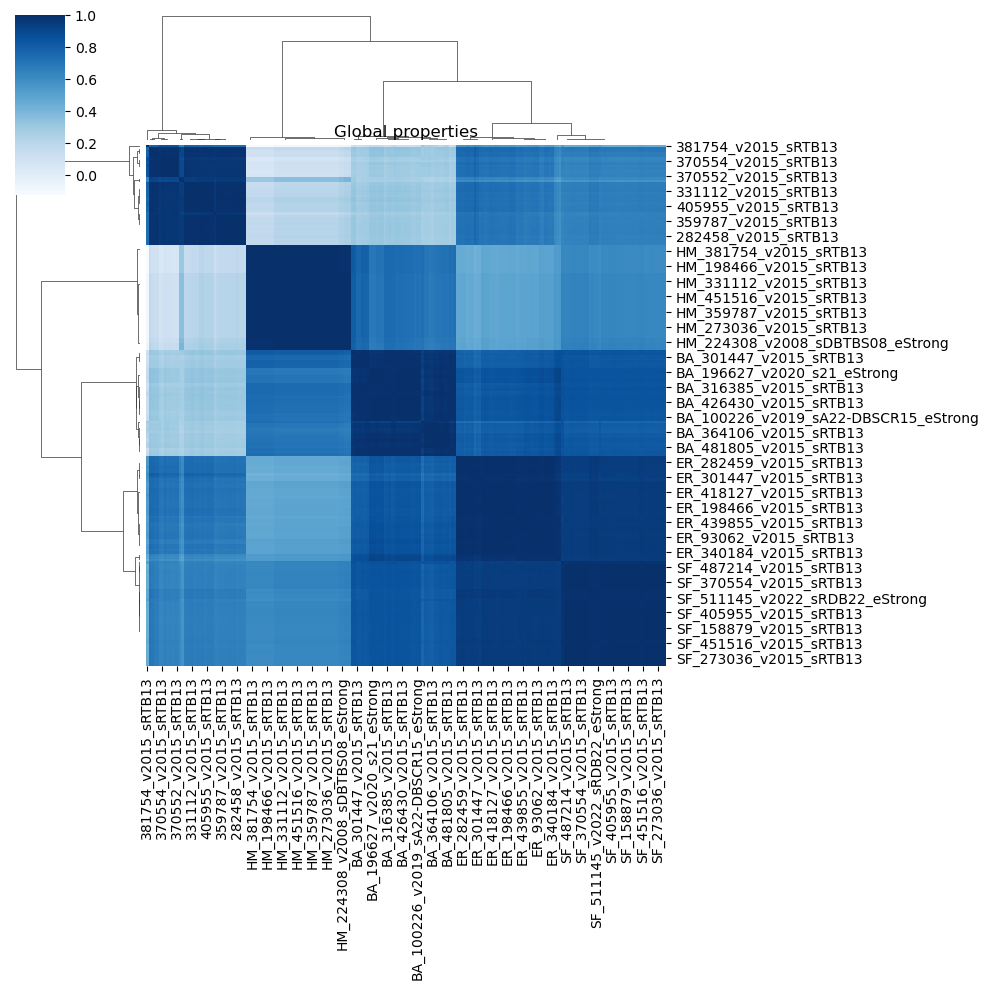

In [18]:
df = pairwise_pearson_correlation(scalar)
fig_scalar, _ = create_symmetric_heatmap(df, title=f"Global properties")

In [25]:
# index = list(corr_df.index)
models = {
    'BA' : 0,
    'SF' : 1,
    'ER' : 2,
    'HM' : 3,
    }

gs = [models.get(name.split('_')[0], 4) for name in df.index] # 4 for biological
result = get_clusters(df, 5, map_ids=False) # 5 clusters

adjusted_rand_score(gs, result)


1.0

In [31]:
scalar

{'160491_v2015_sRTB13': {'Average Clustering Coefficient': 0.02725556149573792,
  'Complex Feed-Forward Circuits': 0.0,
  'Density': 0.007368848025959978,
  'Entropy of Degree Distribution': 0.12902715439817444,
  '3-Feedback Loops': 0.0,
  'Gene % in the Giant Component': 0.8837209302325582,
  'Gini Index': 0.9392468529976531,
  'Max In-Dregree': 0.040697674418604654,
  'Max Out-Degree': 0.1744186046511628,
  'Regulators': 0.12209302325581395,
  'Self-Regulations': 0.03488372093023256,
  'Average Local Efficiency': 0.03201001786074381,
  'Average Shortest Path Length': 0.0300927475480069,
  'Center': 0.006578947368421052,
  'Diameter': 0.06622516556291391,
  'Global Efficiency': 0.2762883339695818,
  'Periphery': 0.18421052631578946,
  'Radius': 0.033112582781456956},
 '186103_v2015_sRTB13': {'Average Clustering Coefficient': 0.06133803245668932,
  'Complex Feed-Forward Circuits': 0.0,
  'Density': 0.007728873841523888,
  'Entropy of Degree Distribution': 0.13405448406866596,
  '3-Fee

In [41]:
# combinatory of scalar properties
props_combinatory = combinations(scalar[example_netid].keys(), 2)

In [45]:
len(scalar[example_netid].keys())

18

In [44]:
len(list(props_combinatory))

153

In [35]:
# index = list(corr_df.index)
models = {
    'BA' : 0,
    'SF' : 1,
    'ER' : 2,
    'HM' : 3,
    }

gs = [models.get(name.split('_')[0], 4) for name in df.index] # 4 for biological

rands = dict()
example_netid = '160491_v2015_sRTB13'
for out_prop in scalar[example_netid].keys():
    loo_dict = {}    
    for net_id in scalar.keys():
        loo_dict[net_id] = {prop: value for prop, value in scalar[net_id].items() if prop!=out_prop}
    
    props = loo_dict[example_netid].keys()
    df = pairwise_pearson_correlation(scalar)
    result = get_clusters(df, 5, map_ids=False) # 5 clusters
    rands[tuple(props)] = adjusted_rand_score(gs, result)
    

In [36]:
sorted(rands.items(), key=lambda x: x[1], reverse=True)[0]

[(('Complex Feed-Forward Circuits',
   'Density',
   'Entropy of Degree Distribution',
   '3-Feedback Loops',
   'Gene % in the Giant Component',
   'Gini Index',
   'Max In-Dregree',
   'Max Out-Degree',
   'Regulators',
   'Self-Regulations',
   'Average Local Efficiency',
   'Average Shortest Path Length',
   'Center',
   'Diameter',
   'Global Efficiency',
   'Periphery',
   'Radius'),
  1.0),
 (('Average Clustering Coefficient',
   'Density',
   'Entropy of Degree Distribution',
   '3-Feedback Loops',
   'Gene % in the Giant Component',
   'Gini Index',
   'Max In-Dregree',
   'Max Out-Degree',
   'Regulators',
   'Self-Regulations',
   'Average Local Efficiency',
   'Average Shortest Path Length',
   'Center',
   'Diameter',
   'Global Efficiency',
   'Periphery',
   'Radius'),
  1.0),
 (('Average Clustering Coefficient',
   'Complex Feed-Forward Circuits',
   'Entropy of Degree Distribution',
   '3-Feedback Loops',
   'Gene % in the Giant Component',
   'Gini Index',
   'Max In-

In [ ]:
# index = list(corr_df.index)
models = {
    'BA' : 0,
    'SF' : 1,
    'ER' : 2,
    'HM' : 3,
    }

gs = [models.get(name.split('_')[0], 4) for name in df.index] # 4 for biological
result = get_clusters(df, 5, map_ids=False) # 5 clusters

adjusted_rand_score(gs, result)


C:\Users\jmere\AppData\Local\Temp\ipykernel_22972\4063097653.py:35: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


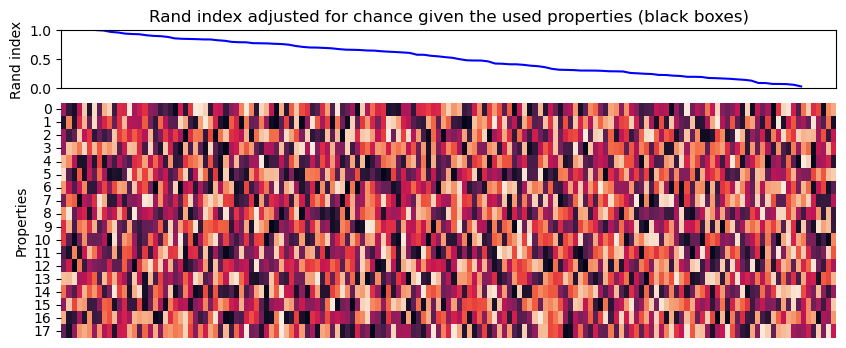

In [78]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Generate random data for the heatmap
data = np.random.rand(18, 153)

# Generate random words for y-axis labels
y_labels = [str(i) for i in range (18)]

# Generate random data for the decreasing function
x = np.linspace(0, 1, 100)
y = np.sort(np.random.rand(100))[::-1]

# Create a figure with a shared x-axis
fig = plt.figure(figsize=(10, 4))
gs = fig.add_gridspec(2, 1, height_ratios=[2, 8], hspace=0.1)  # Swapped height_ratios

# Plot the decreasing function in the first row
ax2 = fig.add_subplot(gs[0])
ax2.plot(x, y, color='blue')
ax2.set_title('Rand index adjusted for chance given the used properties (black boxes)')
ax2.set_ylabel('Rand index')
ax2.set_xticks([])
ax2.set_ylim(0, 1)

# Plot the heatmap in the second row
ax1 = fig.add_subplot(gs[1])
sns.heatmap(data, ax=ax1, cbar=False)  # Set cbar=False to remove colorbar
ax1.set_ylabel('Properties')
ax1.set_yticks(np.arange(18) + 0.5)
ax1.set_yticklabels(y_labels, rotation=0)
ax1.set_xticks([])

plt.tight_layout()
plt.show()


In [61]:
sns.heatmap(data, cmap='viridis', ax=ax1)
plt.show()

In [55]:
data

array([[0.06825847, 0.68598631, 0.8555308 , ..., 0.09327741, 0.88864054,
        0.01231296],
       [0.67518015, 0.61587069, 0.97337356, ..., 0.66248021, 0.22822243,
        0.973453  ],
       [0.00417011, 0.11501871, 0.02331705, ..., 0.86763568, 0.90219322,
        0.41679235],
       ...,
       [0.4217219 , 0.38720824, 0.86312877, ..., 0.13669422, 0.56080381,
        0.86152594],
       [0.56955576, 0.4686406 , 0.06813364, ..., 0.86477865, 0.06087731,
        0.3963916 ],
       [0.32074509, 0.55996066, 0.97420473, ..., 0.09770483, 0.62815205,
        0.20565858]])